<a href="https://colab.research.google.com/github/SofiVell/Machine_Learning/blob/main/%D0%A2%D1%80%D0%B5%D0%BD%D1%83%D0%B2%D0%B0%D0%BB%D1%8C%D0%BD%D0%B8%D0%B9_%D0%BD%D0%BE%D1%83%D1%82%D0%B1%D1%83%D0%BA_%D0%9B%D0%B5%D0%BA%D1%86%D1%96%D1%8F_3_Pandas_EDA_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Тренувальний ноутбук до лекції 3
## Аналіз даних у pandas та EDA

**Дисципліна:** Машинне навчання  
**Редакція:** 2026  

Мета ноутбука - відпрацювати основні операції pandas на єдиному навчальному наборі даних: завантаження, первинне обстеження, індексацію, очищення, групування, об’єднання, переформатування та базову візуалізацію.

> Матеріал орієнтований на pandas 3.0+. Якщо у Google Colab встановлена інша версія, більшість прикладів все одно виконуватиметься, але dtype текстових стовпців може відрізнятися.

## 0. Підготовка середовища

Спочатку імпортуємо бібліотеки та перевіримо версію pandas.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("pandas:", pd.__version__)
print("numpy:", np.__version__)

pandas: 2.2.3
numpy: 2.1.3


## 1. Створення навчального набору даних

Щоб ноутбук був автономним і запускався у Colab без зовнішніх файлів, згенеруємо невеликий набір даних про клієнтів інтернет-магазину. У ньому навмисно є пропуски, дублікати та неакуратні текстові значення.

In [2]:
rng = np.random.default_rng(42)

n = 120
cities = np.array(["Kyiv", "Lviv", "Odesa", "Dnipro", "Kharkiv"])
segments = np.array(["basic", "standard", "premium"])

customers = pd.DataFrame({
    "customer_id": np.arange(1001, 1001 + n),
    "age": rng.integers(18, 70, size=n),
    "city": rng.choice(cities, size=n, p=[0.30, 0.20, 0.18, 0.16, 0.16]),
    "segment": rng.choice(segments, size=n, p=[0.45, 0.40, 0.15]),
    "signup_date": pd.Timestamp("2022-01-01") + pd.to_timedelta(
        rng.integers(0, 1600, size=n), unit="D"
    ),
    "orders": rng.poisson(7, size=n),
    "spend": np.round(rng.gamma(shape=2.3, scale=280, size=n), 2),
    "churn": rng.choice([0, 1], size=n, p=[0.78, 0.22]),
})

# Навмисно додаємо проблеми якості даних
customers.loc[[5, 18, 44], "age"] = np.nan
customers.loc[[9, 27, 78, 101], "spend"] = np.nan
customers.loc[12, "city"] = " kyiv "
customers.loc[31, "city"] = "LVIV"
customers.loc[66, "segment"] = None
customers.loc[88, "spend"] = -150.0

# Додаємо два дублікати рядків
customers = pd.concat([customers, customers.iloc[[3, 15]]], ignore_index=True)

customers.to_csv("customers_eda.csv", index=False)
print("Файл створено: customers_eda.csv")
print("Розмір:", customers.shape)
customers.head()

Файл створено: customers_eda.csv
Розмір: (122, 8)


,customer_id,age,city,segment,signup_date,orders,spend,churn
0,1001,22.0,Odesa,premium,2024-09-13,4,347.14,0
1,1002,58.0,Lviv,premium,2025-05-31,9,706.18,0
2,1003,52.0,Odesa,standard,2025-03-28,11,1164.91,0
3,1004,40.0,Dnipro,basic,2022-08-04,7,77.99,0
4,1005,40.0,Odesa,standard,2025-08-14,8,574.75,0


## 2. Завантаження даних та первинна перевірка

Завантажимо CSV так, як це робиться у реальному проєкті.

In [3]:
df = pd.read_csv(
    "customers_eda.csv",
    parse_dates=["signup_date"],
)

df.head()

,customer_id,age,city,segment,signup_date,orders,spend,churn
0,1001,22.0,Odesa,premium,2024-09-13,4,347.14,0
1,1002,58.0,Lviv,premium,2025-05-31,9,706.18,0
2,1003,52.0,Odesa,standard,2025-03-28,11,1164.91,0
3,1004,40.0,Dnipro,basic,2022-08-04,7,77.99,0
4,1005,40.0,Odesa,standard,2025-08-14,8,574.75,0


In [4]:
df.shape

(122, 8)

In [5]:
df.columns

Index(['customer_id', 'age', 'city', 'segment', 'signup_date', 'orders',
       'spend', 'churn'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122 entries, 0 to 121
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   customer_id  122 non-null    int64         
 1   age          119 non-null    float64       
 2   city         122 non-null    object        
 3   segment      121 non-null    object        
 4   signup_date  122 non-null    datetime64[ns]
 5   orders       122 non-null    int64         
 6   spend        118 non-null    float64       
 7   churn        122 non-null    int64         
dtypes: datetime64[ns](1), float64(2), int64(3), object(2)
memory usage: 7.8+ KB


In [7]:
df.describe()

,customer_id,age,signup_date,orders,spend,churn
count,122.000000,119.000000,122,122.000000,118.000000,122.000000
mean,1059.672131,44.512605,2024-04-23 11:00:59.016393472,6.959016,672.393814,0.278689
min,1001.000000,18.000000,2022-01-13 00:00:00,1.000000,-150.000000,0.000000
25%,1029.250000,33.000000,2023-05-01 06:00:00,5.000000,341.800000,0.000000
50%,1059.500000,44.000000,2024-05-06 12:00:00,7.000000,621.640000,0.000000
75%,1089.750000,57.000000,2025-03-27 06:00:00,8.000000,901.750000,1.000000
max,1120.000000,68.000000,2026-05-14 00:00:00,14.000000,2046.770000,1.000000
std,35.100668,14.038606,NaN,2.556462,445.379828,0.450203


### Зверніть увагу
- `shape` показує кількість об'єктів та ознак;
- `info()` допомагає побачити типи й пропуски;
- `describe()` дає базову статистику числових ознак;
- у pandas 3.0 текстові стовпці за замовчуванням можуть мати `str` dtype замість старого `object`.

## 3. Series, DataFrame, loc та iloc

In [8]:
# Один стовпець -> Series
spend = df["spend"]
print(type(spend))

# Кілька стовпців -> DataFrame
small = df[["customer_id", "city", "spend"]]
print(type(small))
small.head()

<class 'pandas.core.series.Series'>
<class 'pandas.core.frame.DataFrame'>


,customer_id,city,spend
0,1001,Odesa,347.14
1,1002,Lviv,706.18
2,1003,Odesa,1164.91
3,1004,Dnipro,77.99
4,1005,Odesa,574.75


In [9]:
# loc: вибір за мітками / умовами
high_spend = df.loc[df["spend"] > 1000, ["customer_id", "city", "spend"]]
high_spend.head()

,customer_id,city,spend
2,1003,Odesa,1164.91
6,1007,Odesa,1771.49
15,1016,Kyiv,1190.51
19,1020,Dnipro,1632.17
21,1022,Lviv,1162.84


In [10]:
# iloc: вибір за позиціями
df.iloc[:5, :4]

,customer_id,age,city,segment
0,1001,22.0,Odesa,premium
1,1002,58.0,Lviv,premium
2,1003,52.0,Odesa,standard
3,1004,40.0,Dnipro,basic
4,1005,40.0,Odesa,standard


## 4. Фільтрація даних

In [11]:
mask = (
    df["age"].between(25, 45)
    & df["city"].isin(["Kyiv", "Lviv"])
    & df["spend"].notna()
)

selected = df.loc[mask]
selected.head()

,customer_id,age,city,segment,signup_date,orders,spend,churn
8,1009,28.0,Kyiv,standard,2026-03-28,5,409.81,1
10,1011,45.0,Kyiv,premium,2025-08-26,8,134.76,0
16,1017,44.0,Kyiv,standard,2023-02-04,5,425.17,0
21,1022,37.0,Lviv,premium,2024-02-04,8,1162.84,0
30,1031,41.0,Kyiv,standard,2025-03-25,4,851.50,0


In [12]:
# query часто зручний для читабельних числових умов
query_result = df.query("orders >= 8 and spend > 700")
query_result.head()

,customer_id,age,city,segment,signup_date,orders,spend,churn
1,1002,58.0,Lviv,premium,2025-05-31,9,706.18,0
2,1003,52.0,Odesa,standard,2025-03-28,11,1164.91,0
13,1014,57.0,Kyiv,standard,2023-09-09,10,902.89,1
15,1016,58.0,Kyiv,basic,2024-10-20,8,1190.51,1
17,1018,24.0,Odesa,premium,2023-03-03,13,930.86,0


## 5. Пропуски, дублікати та базове очищення

In [13]:
missing = pd.DataFrame({
    "count": df.isna().sum(),
    "share": df.isna().mean(),
}).sort_values("share", ascending=False)

missing

,count,share
spend,4,0.032787
age,3,0.024590
segment,1,0.008197
customer_id,0,0.000000
city,0,0.000000
signup_date,0,0.000000
orders,0,0.000000
churn,0,0.000000


In [14]:
print("Повних дублікатів:", df.duplicated().sum())
print("Дублікатів customer_id:", df.duplicated(subset=["customer_id"]).sum())

Повних дублікатів: 2
Дублікатів customer_id: 2


In [15]:
clean = df.drop_duplicates().copy()

# Негативні витрати трактуємо як помилкове значення
clean.loc[clean["spend"] < 0, "spend"] = np.nan

# Очищення тексту
clean["city"] = clean["city"].str.strip().str.title()
clean["segment"] = clean["segment"].fillna("unknown")

print(clean.shape)
print(clean["city"].value_counts(dropna=False))
print(clean["segment"].value_counts(dropna=False))

(120, 8)
city
Kyiv       38
Lviv       28
Odesa      24
Dnipro     16
Kharkiv    14
Name: count, dtype: int64
segment
basic       58
standard    43
premium     18
unknown      1
Name: count, dtype: int64


### Примітка про ML
У цьому навчальному EDA можна показати заповнення пропусків. Але якщо значення для заповнення (медіана, середнє тощо) використовуватиметься моделлю, його слід оцінювати **лише на train**, бажано всередині `Pipeline`.

In [16]:
# Для дослідницького аналізу створимо окремий стовпець
median_age = clean["age"].median()
clean["age_filled"] = clean["age"].fillna(median_age)

print("Медіана age:", median_age)
clean[["age", "age_filled"]].head(10)

Медіана age: 44.0


,age,age_filled
0,22.0,22.0
1,58.0,58.0
2,52.0,52.0
3,40.0,40.0
4,40.0,40.0
5,NaN,44.0
6,22.0,22.0
7,54.0,54.0
8,28.0,28.0
9,22.0,22.0


## 6. Робота з датами та створення ознак

In [17]:
reference_date = pd.Timestamp("2026-09-07")

clean["signup_year"] = clean["signup_date"].dt.year
clean["signup_month"] = clean["signup_date"].dt.month
clean["tenure_days"] = (reference_date - clean["signup_date"]).dt.days
clean["spend_per_order"] = clean["spend"] / clean["orders"].replace(0, np.nan)

clean[[
    "signup_date", "signup_year", "signup_month",
    "tenure_days", "spend_per_order"
]].head()

,signup_date,signup_year,signup_month,tenure_days,spend_per_order
0,2024-09-13,2024,9,724,86.785000
1,2025-05-31,2025,5,464,78.464444
2,2025-03-28,2025,3,528,105.900909
3,2022-08-04,2022,8,1495,11.141429
4,2025-08-14,2025,8,389,71.843750


## 7. Сортування, groupby та агрегування

In [18]:
top_customers = clean.sort_values("spend", ascending=False).head(10)
top_customers[["customer_id", "city", "segment", "spend"]]

,customer_id,city,segment,spend
34,1035,Lviv,standard,2046.77
67,1068,Kyiv,basic,1972.21
6,1007,Odesa,basic,1771.49
59,1060,Odesa,basic,1653.40
29,1030,Odesa,standard,1651.09
19,1020,Dnipro,basic,1632.17
99,1100,Dnipro,premium,1528.80
84,1085,Lviv,premium,1386.54
57,1058,Dnipro,standard,1358.35
51,1052,Kyiv,basic,1355.64


In [19]:
city_summary = (
    clean.groupby("city", dropna=False)
         .agg(
             customers=("customer_id", "nunique"),
             avg_spend=("spend", "mean"),
             median_spend=("spend", "median"),
             total_spend=("spend", "sum"),
             churn_rate=("churn", "mean"),
         )
         .sort_values("total_spend", ascending=False)
)

city_summary.round(2)

,customers,avg_spend,median_spend,total_spend,churn_rate
city,,,,,
Kyiv,38,678.75,682.37,25792.35,0.26
Lviv,28,705.33,704.74,17633.17,0.21
Odesa,24,655.27,527.90,15726.52,0.38
Dnipro,16,688.37,479.96,10325.49,0.19
Kharkiv,14,672.80,637.44,8746.44,0.36


In [20]:
# transform повертає результат тієї самої довжини, що й початкові дані
city_total = clean.groupby("city")["spend"].transform("sum")
clean["share_in_city"] = clean["spend"] / city_total

clean[["customer_id", "city", "spend", "share_in_city"]].head()

,customer_id,city,spend,share_in_city
0,1001,Odesa,347.14,0.022074
1,1002,Lviv,706.18,0.040048
2,1003,Odesa,1164.91,0.074073
3,1004,Dnipro,77.99,0.007553
4,1005,Odesa,574.75,0.036547


## 8. merge та concat

In [21]:
city_info = pd.DataFrame({
    "city": ["Kyiv", "Lviv", "Odesa", "Dnipro", "Kharkiv"],
    "region": ["North", "West", "South", "Center", "East"],
    "priority_market": [1, 1, 0, 0, 1],
})

merged = clean.merge(
    city_info,
    on="city",
    how="left",
    validate="many_to_one",
    indicator=True,
)

print(merged["_merge"].value_counts())
merged.head()

_merge
both          120
left_only       0
right_only      0
Name: count, dtype: int64


,customer_id,age,city,segment,signup_date,orders,spend,churn,age_filled,signup_year,signup_month,tenure_days,spend_per_order,share_in_city,region,priority_market,_merge
0,1001,22.0,Odesa,premium,2024-09-13,4,347.14,0,22.0,2024,9,724,86.785000,0.022074,South,0,both
1,1002,58.0,Lviv,premium,2025-05-31,9,706.18,0,58.0,2025,5,464,78.464444,0.040048,West,1,both
2,1003,52.0,Odesa,standard,2025-03-28,11,1164.91,0,52.0,2025,3,528,105.900909,0.074073,South,0,both
3,1004,40.0,Dnipro,basic,2022-08-04,7,77.99,0,40.0,2022,8,1495,11.141429,0.007553,Center,0,both
4,1005,40.0,Odesa,standard,2025-08-14,8,574.75,0,40.0,2025,8,389,71.843750,0.036547,South,0,both


In [22]:
first_half = clean.iloc[:60]
second_half = clean.iloc[60:]
restored = pd.concat([first_half, second_half], ignore_index=True)

print(clean.shape, restored.shape)

(120, 14) (120, 14)


## 9. pivot_table, crosstab та melt

In [23]:
pivot = pd.pivot_table(
    clean,
    values="spend",
    index="city",
    columns="segment",
    aggfunc="mean",
    fill_value=0,
)

pivot.round(2)

segment,basic,premium,standard,unknown
city,,,,
Dnipro,638.73,979.02,583.47,0.00
Kharkiv,602.54,762.48,750.92,0.00
Kyiv,715.81,598.02,657.28,0.00
Lviv,706.03,700.24,696.94,777.76
Odesa,730.47,639.00,605.72,0.00


In [24]:
churn_table = pd.crosstab(
    clean["segment"],
    clean["churn"],
    normalize="index",
)

churn_table.round(3)

churn,0,1
segment,,
basic,0.759,0.241
premium,0.778,0.222
standard,0.674,0.326
unknown,0.000,1.000


In [25]:
wide = city_summary.reset_index()[["city", "avg_spend", "churn_rate"]]
long = wide.melt(
    id_vars="city",
    var_name="metric",
    value_name="value",
)
long.head(10)

,city,metric,value
0,Kyiv,avg_spend,678.746053
1,Lviv,avg_spend,705.326800
2,Odesa,avg_spend,655.271667
3,Dnipro,avg_spend,688.366000
4,Kharkiv,avg_spend,672.803077
5,Kyiv,churn_rate,0.263158
6,Lviv,churn_rate,0.214286
7,Odesa,churn_rate,0.375000
8,Dnipro,churn_rate,0.187500
9,Kharkiv,churn_rate,0.357143


## 10. Кореляція та пошук потенційних викидів

In [26]:
numeric_cols = ["age", "orders", "spend", "churn", "tenure_days"]
correlation = clean[numeric_cols].corr(method="pearson")
correlation.round(2)

,age,orders,spend,churn,tenure_days
age,1.00,-0.05,-0.08,0.08,0.01
orders,-0.05,1.00,-0.08,-0.05,-0.07
spend,-0.08,-0.08,1.00,-0.01,-0.02
churn,0.08,-0.05,-0.01,1.00,-0.15
tenure_days,0.01,-0.07,-0.02,-0.15,1.00


In [27]:
q1 = clean["spend"].quantile(0.25)
q3 = clean["spend"].quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers = clean.loc[~clean["spend"].between(lower, upper) & clean["spend"].notna()]
print("Межі IQR:", round(lower, 2), round(upper, 2))
print("Кількість потенційних викидів:", len(outliers))
outliers[["customer_id", "city", "spend"]].head()

Межі IQR: -480.7 1729.4
Кількість потенційних викидів: 3


,customer_id,city,spend
6,1007,Odesa,1771.49
34,1035,Lviv,2046.77
67,1068,Kyiv,1972.21


## 11. Базова візуалізація

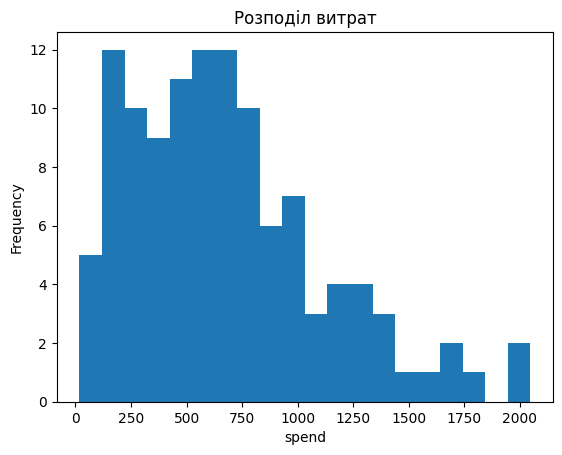

In [28]:
clean["spend"].plot(kind="hist", bins=20, title="Розподіл витрат")
plt.xlabel("spend")
plt.show()

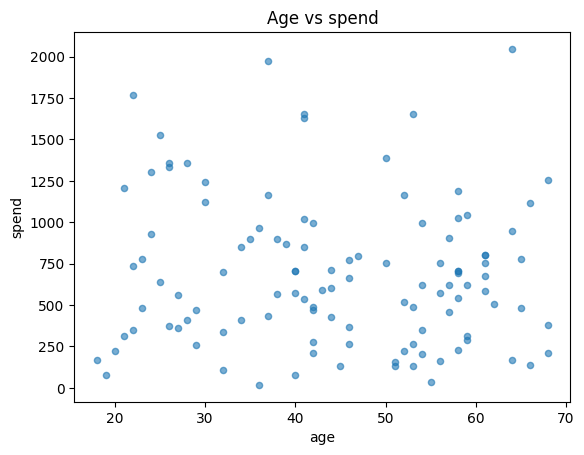

In [29]:
clean.plot.scatter(x="age", y="spend", alpha=0.6, title="Age vs spend")
plt.show()

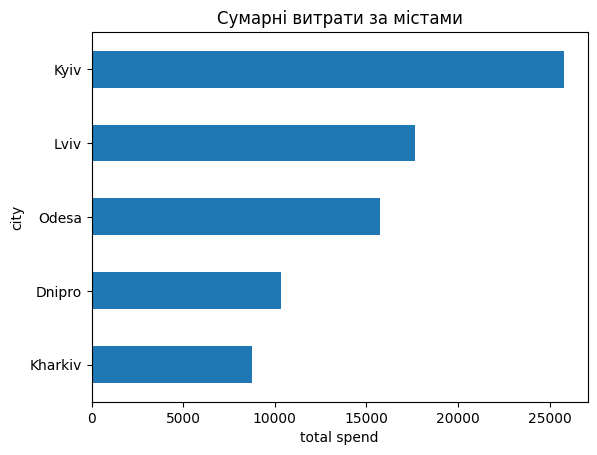

In [30]:
city_summary["total_spend"].sort_values().plot(
    kind="barh",
    title="Сумарні витрати за містами",
)
plt.xlabel("total spend")
plt.show()

## 12. EDA і data leakage

Нижче показано лише **правильну послідовність**: спочатку train/test split, потім статистики preprocessing оцінюються на train.

In [31]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    clean,
    test_size=0.2,
    random_state=42,
    stratify=clean["churn"],
)

train_median = train_df["age"].median()
train_age = train_df["age"].fillna(train_median)
test_age = test_df["age"].fillna(train_median)

print("train:", train_df.shape)
print("test:", test_df.shape)
print("Медіана, оцінена лише на train:", train_median)

train: (96, 14)
test: (24, 14)
Медіана, оцінена лише на train: 44.0


# Завдання для студентів

Виконайте завдання нижче самостійно. Після кожного завдання додайте короткий висновок у Markdown-комірці: **що саме було виявлено і чому це важливо**.

## Завдання 1. Первинний аудит даних
1. Визначте розмір `df`.
2. Виведіть типи всіх стовпців.
3. Порахуйте кількість унікальних значень у кожному стовпці.
4. Визначте частку пропусків.
5. Назвіть щонайменше три потенційні проблеми якості даних.

In [32]:
print("Розмір df:", df.shape)

print("\nТипи стовпців:")
print(df.dtypes)

print("\nКількість унікальних значень:")
print(df.nunique())

print("\nЧастка пропусків:")
print(df.isna().mean().round(4))

Розмір df: (122, 8)

Типи стовпців:
customer_id             int64
age                   float64
city                   object
segment                object
signup_date    datetime64[ns]
orders                  int64
spend                 float64
churn                   int64
dtype: object

Кількість унікальних значень:
customer_id    120
age             45
city             7
segment          3
signup_date    117
orders          14
spend          116
churn            2
dtype: int64

Частка пропусків:
customer_id    0.0000
age            0.0246
city           0.0000
segment        0.0082
signup_date    0.0000
orders         0.0000
spend          0.0328
churn          0.0000
dtype: float64


Набір даних містить 122 рядки та 8 стовпців. У ньому є числові, текстові та датовані ознаки. Виявлено пропуски в `age`, `segment` та `spend`. Також є дублікати рядків неузгоджене написання назв міст та від'ємне значення `spend`. Ці проблеми важливо виправити, оскільки вони можуть спотворювати результати подальшого аналізу.

## Завдання 2. Фільтрація
Створіть DataFrame `task2`, який містить клієнтів:
- віком від 30 до 50 років;
- із сегменту `premium` або `standard`;
- з витратами понад 600;
- лише зі стовпцями `customer_id`, `age`, `city`, `segment`, `spend`.

Відсортуйте результат за `spend` за спаданням.

In [33]:
task2 = df.loc[
    (df["age"].between(30, 50)) &
    (df["segment"].isin(["premium", "standard"])) &
    (df["spend"] > 600),
    ["customer_id", "age", "city", "segment", "spend"]
].sort_values("spend", ascending=False)

task2


,customer_id,age,city,segment,spend
29,1030,41.0,Odesa,standard,1651.09
84,1085,50.0,Lviv,premium,1386.54
118,1119,30.0,Kharkiv,standard,1243.22
21,1022,37.0,Lviv,premium,1162.84
75,1076,42.0,Kyiv,standard,997.35
43,1044,36.0,Kharkiv,premium,963.23
76,1077,35.0,Kharkiv,standard,898.33
64,1065,39.0,Kyiv,standard,870.96
30,1031,41.0,Kyiv,standard,851.50
65,1066,34.0,Lviv,premium,848.28


В результаті отримано 16 клієнтів віком від 30 до 50 років із сегментів premium або standard та витратами понад 600. Сортування показує клієнтів із найбільшими витратами першими, що зручно для подальшого аналізу цінних клієнтів.

## Завдання 3. Очищення
На копії `df` виконайте:
1. видалення повних дублікатів;
2. очищення пробілів і регістру в `city`;
3. заміну від’ємних `spend` на пропуск;
4. підрахунок кількості пропусків після очищення;
5. поясніть, які пропуски ви б видаляли, а які — імпутували.

In [36]:
clean = df.copy()

clean = clean.drop_duplicates()

clean["city"] = clean["city"].str.strip().str.title()

clean.loc[clean["spend"] < 0, "spend"] = np.nan

missing_after = pd.DataFrame({
    "count": clean.isna().sum(),
    "share": clean.isna().mean()
}).sort_values("count", ascending=False)

missing_after


,count,share
spend,5,0.041667
age,3,0.025000
segment,1,0.008333
customer_id,0,0.000000
city,0,0.000000
signup_date,0,0.000000
orders,0,0.000000
churn,0,0.000000


In [37]:
print("Розмір після очищення:", clean.shape)

Розмір після очищення: (120, 8)


Після видалення дублікатів залишилося 120 клієнтів, від'ємне значення витрат було замінено на пропуск, а значення `city` приведено до єдиного формату. Пропуски в `age` та `spend` доцільно імпутувати, наприклад медіаною, якщо їх частка невелика. Видаляти рядки варто лише тоді, коли пропусків багато або рядок неможливо коректно використати.

## Завдання 4. Групова аналітика
Для кожного `segment` обчисліть:
- кількість клієнтів;
- середню кількість замовлень;
- медіанні витрати;
- сумарні витрати;
- churn rate.

Відсортуйте сегменти за churn rate від найбільшого до найменшого.

In [38]:
task4 = (
    clean.groupby("segment")
    .agg(
        customers=("customer_id", "count"),
        avg_orders=("orders", "mean"),
        median_spend=("spend", "median"),
        total_spend=("spend", "sum"),
        churn_rate=("churn", "mean")
    )
    .sort_values("churn_rate", ascending=False)
)

task4["churn_rate"] = task4["churn_rate"] * 100

task4.round(2)

,customers,avg_orders,median_spend,total_spend,churn_rate
segment,,,,,
standard,43,7.00,503.86,27178.88,32.56
basic,58,6.79,668.14,37335.78,24.14
premium,18,7.39,738.40,12931.55,22.22


Найвищий churn rate серед основних сегментів має standard — 32.56%, тоді як у basic він становить 24.14%, а у premium — 22.22%. Сегмент basic має найбільшу кількість клієнтів і найбільші сумарні витрати.

## Завдання 5. Ознаки на основі дат
Створіть:
- `signup_year`;
- `signup_quarter`;
- `tenure_days` станом на 07.09.2026.

Після цього визначте, у якому році зареєструвалося найбільше клієнтів.

In [39]:
reference_date = pd.Timestamp("2026-09-07")

clean["signup_year"] = clean["signup_date"].dt.year
clean["signup_quarter"] = clean["signup_date"].dt.quarter

clean["tenure_days"] = (
    reference_date - clean["signup_date"]
).dt.days

print("Кількість клієнтів за роками:")
print(clean["signup_year"].value_counts().sort_index())

print("\nРік із найбільшою кількістю реєстрацій:",
      clean["signup_year"].value_counts().idxmax())


Кількість клієнтів за роками:
signup_year
2022    22
2023    21
2024    37
2025    27
2026    13
Name: count, dtype: int64

Рік із найбільшою кількістю реєстрацій: 2024


Було створено ознаки `signup_year`, `signup_quarter` та `tenure_days`. Найбільше клієнтів зареєструвалося у 2024 році — 37 клієнтів.

## Завдання 6. Об’єднання таблиць
Створіть окрему таблицю `segment_info` з полями:
- `segment`;
- `discount_rate`;
- `support_level`.

Об’єднайте її з очищеним набором через `merge`. Обов’язково використайте `validate` і поясніть, який тип зв’язку очікується.

In [43]:
segment_info = pd.DataFrame({
    "segment": ["basic", "standard", "premium"],
    "discount_rate": [0.05, 0.10, 0.20],
    "support_level": ["low", "medium", "high"]
})

df_merged = clean.merge(
    segment_info,
    on="segment",
    how="left",
    validate="many_to_one"
)

df_merged.head()

,customer_id,age,city,segment,signup_date,orders,spend,churn,signup_year,signup_quarter,tenure_days,discount_rate,support_level
0,1001,22.0,Odesa,premium,2024-09-13,4,347.14,0,2024,3,724,0.20,high
1,1002,58.0,Lviv,premium,2025-05-31,9,706.18,0,2025,2,464,0.20,high
2,1003,52.0,Odesa,standard,2025-03-28,11,1164.91,0,2025,1,528,0.10,medium
3,1004,40.0,Dnipro,basic,2022-08-04,7,77.99,0,2022,3,1495,0.05,low
4,1005,40.0,Odesa,standard,2025-08-14,8,574.75,0,2025,3,389,0.10,medium


Очікується зв'язок many-to-one: багато клієнтів можуть належати до одного сегмента, але кожен сегмент у таблиці `segment_info` повинен бути представлений лише один раз. Тому використано `validate="many_to_one"`. Це дозволяє автоматично виявити помилку, якщо в довіднику сегментів з'являться дублікати.

## Завдання 7. Pivot table
Побудуйте `pivot_table`, де:
- рядки — `city`;
- стовпці — `segment`;
- значення — медіана `spend`.

Визначте комбінацію місто–сегмент із найбільшою медіаною витрат.

In [44]:
pivot = pd.pivot_table(
    clean,
    index="city",
    columns="segment",
    values="spend",
    aggfunc="median"
)

pivot.round(2)

segment,basic,premium,standard
city,,,
Dnipro,703.23,1254.48,456.84
Kharkiv,533.90,762.48,767.88
Kyiv,663.68,701.06,727.90
Lviv,679.78,777.23,425.10
Odesa,672.59,639.00,489.18


In [45]:
max_city, max_segment = pivot.stack().idxmax()
max_value = pivot.stack().max()

print("Місто:", max_city)
print("Сегмент:", max_segment)
print("Медіана spend:", max_value)

Місто: Dnipro
Сегмент: premium
Медіана spend: 1254.48


Найбільша медіана витрат спостерігається у клієнтів premium у місті Dnipro і становить 1254.48. Це означає, що серед типових клієнтів цієї комбінації міста та сегмента рівень витрат є найвищим у наборі даних.

## Завдання 8. Візуалізація
Побудуйте щонайменше три різні графіки:
1. розподіл `age`;
2. boxplot `spend` за сегментами;
3. churn rate за містами.

Для кожного графіка напишіть 1–2 речення інтерпретації.

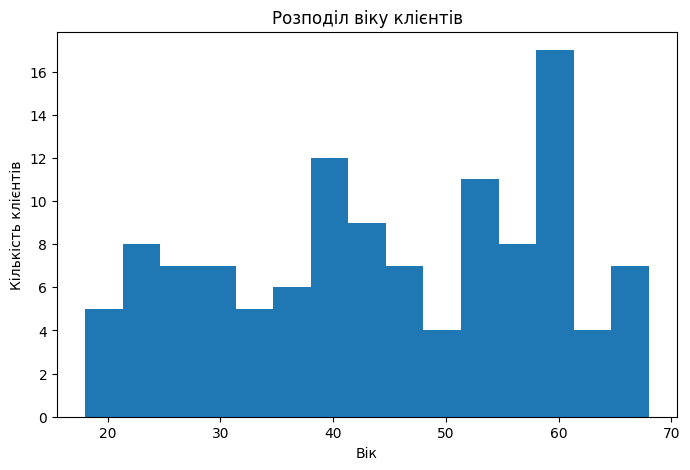

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(clean["age"].dropna(), bins=15)

plt.title("Розподіл віку клієнтів")
plt.xlabel("Вік")
plt.ylabel("Кількість клієнтів")

plt.show()

У наборі представлені клієнти віком приблизно від 18 до 68 років, тому аудиторія є досить різноманітною. Розподіл віку показує, що основна частина клієнтів зосереджена в групі клієнтів 50-60 років.

<Figure size 800x500 with 0 Axes>

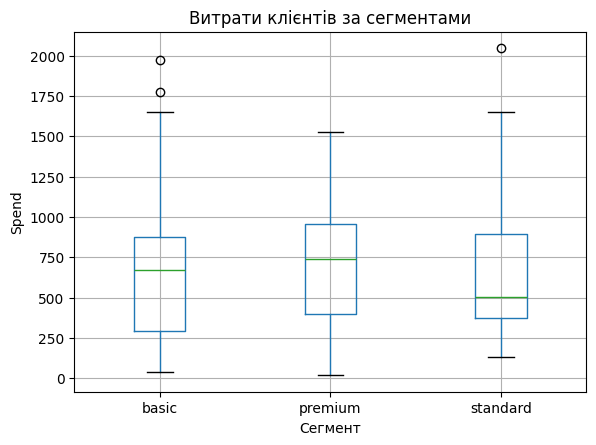

In [47]:
plt.figure(figsize=(8, 5))

clean.boxplot(
    column="spend",
    by="segment"
)

plt.title("Витрати клієнтів за сегментами")
plt.suptitle("")
plt.xlabel("Сегмент")
plt.ylabel("Spend")

plt.show()

Boxplot дозволяє порівняти медіану та розкид витрат між сегментами. У premium медіана витрат вища, ніж у standard.

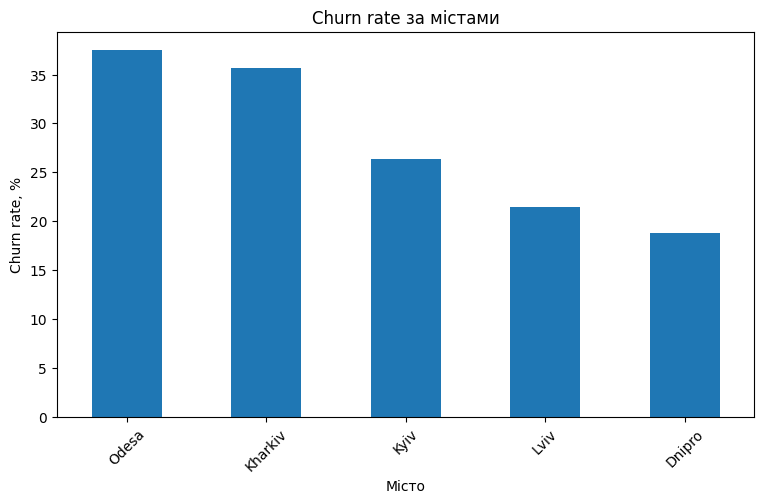

In [48]:
churn_by_city = (
    clean.groupby("city")["churn"]
    .mean()
    .sort_values(ascending=False) * 100
)

plt.figure(figsize=(9, 5))

churn_by_city.plot(kind="bar")

plt.title("Churn rate за містами")
plt.xlabel("Місто")
plt.ylabel("Churn rate, %")
plt.xticks(rotation=45)

plt.show()

Найвищий churn rate спостерігається в Odesa — 38%, а найнижчий у Dnipro — 18%. Це може свідчити про відмінності у поведінці клієнтів між містами та потребує додаткового аналізу причин відтоку.

## Завдання 9. Викиди
За правилом IQR знайдіть потенційні викиди `spend`.

Далі порівняйте середнє та медіану `spend` до і після **тимчасового** виключення цих рядків. Не видаляйте викиди з фінального DataFrame автоматично. Поясніть, чому.

In [49]:
q1 = clean["spend"].quantile(0.25)
q3 = clean["spend"].quantile(0.75)

iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers = clean.loc[
    ~clean["spend"].between(lower, upper) &
    clean["spend"].notna()
]

print("Q1:", round(q1, 2))
print("Q3:", round(q3, 2))
print("IQR:", round(iqr, 2))
print("Нижня межа:", round(lower, 2))
print("Верхня межа:", round(upper, 2))
print("Кількість потенційних викидів:", len(outliers))

outliers[["customer_id", "city", "spend"]]


Q1: 348.08
Q3: 900.61
IQR: 552.53
Нижня межа: -480.7
Верхня межа: 1729.4
Кількість потенційних викидів: 3


,customer_id,city,spend
6,1007,Odesa,1771.49
34,1035,Lviv,2046.77
67,1068,Kyiv,1972.21


In [50]:
mean_before = clean["spend"].mean()
median_before = clean["spend"].median()

clean_without_outliers = clean.loc[
    ~clean.index.isin(outliers.index)
]

mean_after = clean_without_outliers["spend"].mean()
median_after = clean_without_outliers["spend"].median()

comparison = pd.DataFrame({
    "До виключення": [mean_before, median_before],
    "Після виключення": [mean_after, median_after]
}, index=["Середнє", "Медіана"])

comparison.round(2)

,До виключення,Після виключення
Середнє,680.21,646.73
Медіана,623.25,612.16


За правилом IQR було виявлено 3 потенційні викиди у `spend`: 1771.49, 2046.77 та 1972.21. Після їх тимчасового виключення середнє зменшилося з 680.21 до 646.73, тоді як медіана змінилася з 623.25 до 612.16. Викиди не потрібно автоматично видаляти з фінального DataFrame, оскільки вони можуть бути реальними клієнтами з високими витратами, а не помилками в даних.

## Завдання 10. Підсумковий EDA
Підготуйте короткий аналітичний висновок за набором даних. Він має містити:
- розмір і структуру даних;
- проблеми якості;
- 3–5 ключових статистичних спостережень;
- щонайменше 2 візуальні спостереження;
- потенційні ознаки для ML-моделі прогнозування `churn`;
- ризики data leakage;
- план preprocessing перед моделюванням.

Початковий набір даних містить 122 рядки та 8 стовпців. Після видалення двох повних дублікатів залишилося 120 клієнтів. Дані містять числові, категоріальні та датовані ознаки: вік, місто, сегмент, дату реєстрації, кількість замовлень, витрати та ознаку churn.

Під час первинного аудиту було виявлено пропуски в `age`, `segment` та `spend`, дублікати рядків, неузгоджене написання назв міст та від'ємне значення `spend`. Після очищення від'ємне значення витрат було замінено на пропуск, а значення `city` приведено до єдиного формату.

Серед основних статистичних спостережень можна виділити такі:
1. Найбільшу кількість клієнтів має сегмент basic — 58 клієнтів.
2. Найвищий churn rate серед основних сегментів має standard — 32.56%.
3. Сегмент basic має найбільші сумарні витрати — 37335.78.
4. Найбільше клієнтів зареєструвалося у 2024 році — 37 клієнтів.
5. Найбільша медіана витрат спостерігається для premium-клієнтів у Dnipro — 1254.48.

Візуальний аналіз показав, що клієнти мають широкий віковий діапазон. Boxplot витрат демонструє відмінності між сегментами та наявність окремих дуже великих значень. За містами найвищий churn rate спостерігається в Odesa — 38%, а найнижчий у Dnipro — 18%.

Для ML-моделі прогнозування `churn` потенційними ознаками можуть бути `age`, `city`, `segment`, `spend`, `orders`, `tenure_days`, `signup_year` та `signup_quarter`. Категоріальні ознаки перед моделюванням потрібно закодувати, а пропуски обробити відповідним способом.

Основний ризик data leakage полягає у використанні інформації, яка стала відома вже після моменту, коли необхідно було зробити прогноз churn. Також статистики для preprocessing, наприклад медіана для заповнення пропусків, потрібно обчислювати тільки на train-вибірці, а потім застосовувати до test. Для цього доцільно використовувати Pipeline.

Перед моделюванням план preprocessing має включати видалення або обґрунтоване опрацювання дублікатів, очищення категоріальних значень, обробку пропусків, перевірку викидів, кодування категоріальних змінних, розділення даних на train/test та виконання preprocessing всередині Pipeline. Потенційні викиди не слід автоматично видаляти без перевірки їхнього бізнес-змісту.

## Критерії самоперевірки

Робота виконана якісно, якщо:
- код запускається послідовно без помилок;
- вихідний DataFrame не змінюється випадково через неявні присвоєння;
- для вибірки за умовами використано `loc`;
- пропуски й дублікати не обробляються без пояснення;
- `merge` перевіряє очікувану кардинальність через `validate`;
- графіки мають назви та зрозумілі осі;
- висновки містять інтерпретацію, а не лише перелік чисел;
- при переході до ML враховано ризик витоку даних.